# Evaluate Model v2 — Stage 1 & Stage 2

Evaluate RT-DETR v2 models trained with two-stage strategy:

- **Stage 1**: Pre-trained on synthetic data (`kaya-go/moku-v2`, revision `stage1`)
- **Stage 2**: Fine-tuned on real data with LR sweep (`stage2-lr2e-4_run_3`, `stage2-lr5e-4_run_3`, `stage2-lr1e-3_run_3`)

**Sections:**

1. Load datasets and models (stage 1 + 3 stage 2 LR runs)
2. Compute mAP metrics (per stage/LR)
3. Side-by-side comparison table
4. Visualize predictions (best stage 2 vs stage 1 vs GT)


In [14]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from datasets import load_dataset
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

from moku.dataset import CATEGORIES, ID_TO_CATEGORY
from moku.training import (
    collate_fn,
    evaluate_center_distance,
    evaluate_map,
    format_center_distance_results,
    make_eval_transform,
    sweep_confidence_threshold,
)
from moku.viz import plot_center_distance_comparison, plot_map_comparison, plot_threshold_sweep

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration


In [2]:
import re

from huggingface_hub import list_repo_refs

HF_MODEL = "kaya-go/moku-v2"
HF_DATASET = "kaya-go/moku-v2"
THRESHOLD = 0.05

# Dynamically discover stage2 branches from the HF model repo
refs = list_repo_refs(HF_MODEL)
STAGE2_RUNS = {}
for branch in refs.branches:
    m = re.match(r"stage2-lr([\de\-]+)_(run_\d+)", branch.name)
    if m:
        lr_str = m.group(1)
        run_id = m.group(2)
        label = f"lr={lr_str} ({run_id})"
        STAGE2_RUNS[label] = branch.name

print(f"Discovered {len(STAGE2_RUNS)} stage 2 branches:")
for label, rev in sorted(STAGE2_RUNS.items()):
    print(f"  {label} → {rev}")

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nDevice: {device}")

Discovered 7 stage 2 branches:
  lr=1e-3 (run_3) → stage2-lr1e-3_run_3
  lr=1e-4 (run_2) → stage2-lr1e-4_run_2
  lr=2e-4 (run_2) → stage2-lr2e-4_run_2
  lr=2e-4 (run_3) → stage2-lr2e-4_run_3
  lr=5e-4 (run_3) → stage2-lr5e-4_run_3
  lr=5e-5 (run_2) → stage2-lr5e-5_run_2
  lr=8e-5 (run_2) → stage2-lr8e-5_run_2

Device: mps


## Load Datasets


In [5]:
# Synthetic dataset (stage 1 eval)
ds_synthetic = load_dataset(HF_DATASET, "synthetic")

# Real dataset (stage 2 eval)
ds_real = load_dataset(HF_DATASET, "real")

## Load Models

Stage 1 from branch `stage1`, Stage 2 from per-LR branches.


In [ ]:
def _load_model(revision: str):
    ip = RTDetrImageProcessor.from_pretrained(HF_MODEL, revision=revision)
    model = RTDetrForObjectDetection.from_pretrained(
        HF_MODEL,
        revision=revision,
        num_labels=len(CATEGORIES),
        id2label=ID_TO_CATEGORY,
        label2id=CATEGORIES,
    )
    return ip, model


# Stage 1
print("Stage 1:")
ip_stage1, model_stage1 = _load_model("stage1")

# Stage 2 LR sweep
stage2_models = {}
for label, revision in STAGE2_RUNS.items():
    print(f"Stage 2 ({label}):")
    try:
        ip, model = _load_model(revision)
        stage2_models[label] = {"ip": ip, "model": model, "revision": revision}
    except Exception as e:
        print(f"  ⚠ Not found (not trained yet?): {e}")

Stage 1:


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Stage 2 (lr=2e-4 (run_3)):


model.safetensors:   0%|          | 0.00/80.5M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Stage 2 (lr=8e-5 (run_2)):


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Stage 2 (lr=2e-4 (run_2)):


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

## Stage 1 — mAP on Synthetic Validation & Real Test


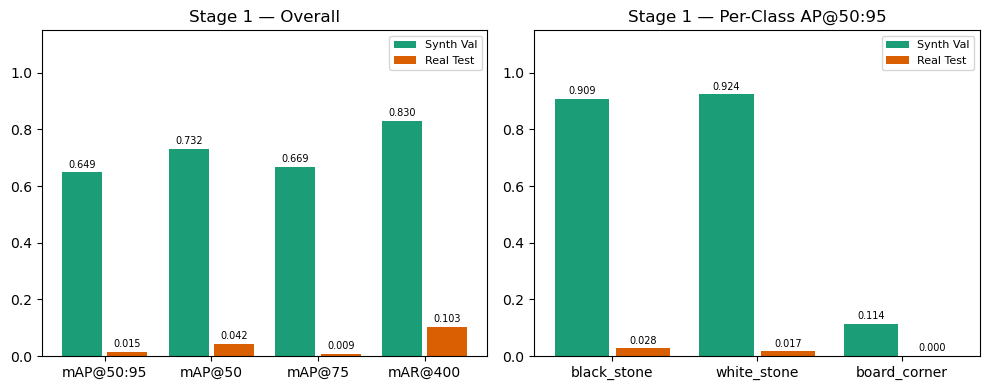

In [ ]:
# --- Synthetic Validation ---
ds_synthetic.set_transform(make_eval_transform(ip_stage1))
metrics_s1_synth = evaluate_map(
    model=model_stage1,
    dataset=ds_synthetic["validation"],
    image_processor=ip_stage1,
    batch_size=8,
    threshold=THRESHOLD,
)

# --- Real Test ---
ds_real.set_transform(make_eval_transform(ip_stage1))
metrics_s1_real = evaluate_map(
    model=model_stage1,
    dataset=ds_real["test"],
    image_processor=ip_stage1,
    batch_size=8,
    threshold=THRESHOLD,
)

plot_map_comparison(
    {"Synth Val": metrics_s1_synth, "Real Test": metrics_s1_real},
    title="Stage 1",
)

## Confidence Threshold Sweep

Find the optimal confidence threshold by sweeping P/R/F1 (center-distance @2%) vs score threshold.
Inference runs only once per model — threshold filtering is applied post-hoc.


Sweeping confidence threshold for best model: lr=2e-4 (run_3)


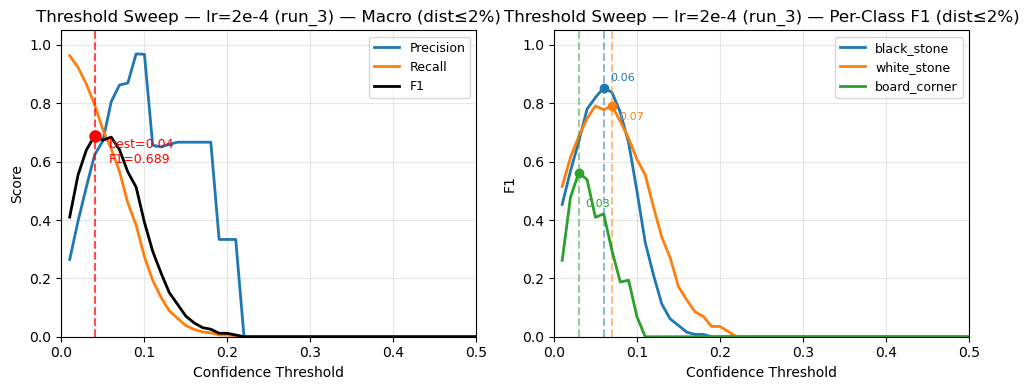

In [21]:
# Pick the best stage 2 model (highest macro F1@2% center-distance)
best_label = max(
    cd_s2, key=lambda l: np.mean([cd_s2[l]["per_class"][c]["thresholds"]["2%"]["f1"] for c in ID_TO_CATEGORY.values()])
)
best_entry = stage2_models[best_label]
print(f"Sweeping confidence threshold for best model: {best_label}")


ds_real.set_transform(make_eval_transform(best_entry["ip"]))
sweep = sweep_confidence_threshold(
    model=best_entry["model"],
    dataset=ds_real["test"],
    image_processor=best_entry["ip"],
    batch_size=8,
    distance_threshold=0.02,
)

plot_threshold_sweep(sweep, title=f"Threshold Sweep — {best_label}")

## Stage 2 — mAP on Real Test (all LR runs)


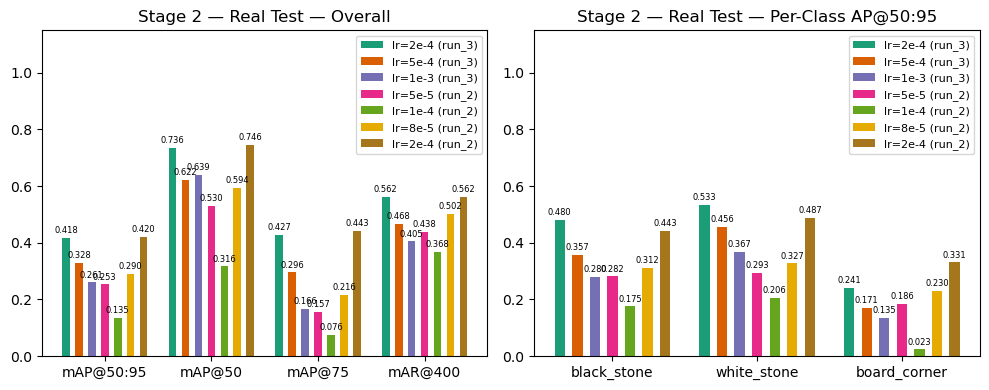

In [26]:
THRESHOLD = 0.03

metrics_s2 = {}

if not stage2_models:
    print("No stage 2 models available yet — skipping.")
else:
    for label, entry in stage2_models.items():
        ds_real.set_transform(make_eval_transform(entry["ip"]))
        metrics_s2[label] = evaluate_map(
            model=entry["model"],
            dataset=ds_real["test"],
            image_processor=entry["ip"],
            batch_size=8,
            threshold=THRESHOLD,
        )

    plot_map_comparison(metrics_s2, title="Stage 2 — Real Test")

## Center-Distance Evaluation

mAP penalizes bbox size mismatches, but for our use case only the **center point** matters:

- **board_corner**: center → homography point
- **stones**: center → snap to nearest grid intersection

The center-distance metric reports Precision/Recall/F1 at various distance thresholds
(as % of image diagonal). A detection is "correct" if its center is within X% of the
diagonal from the nearest GT center of the same class.


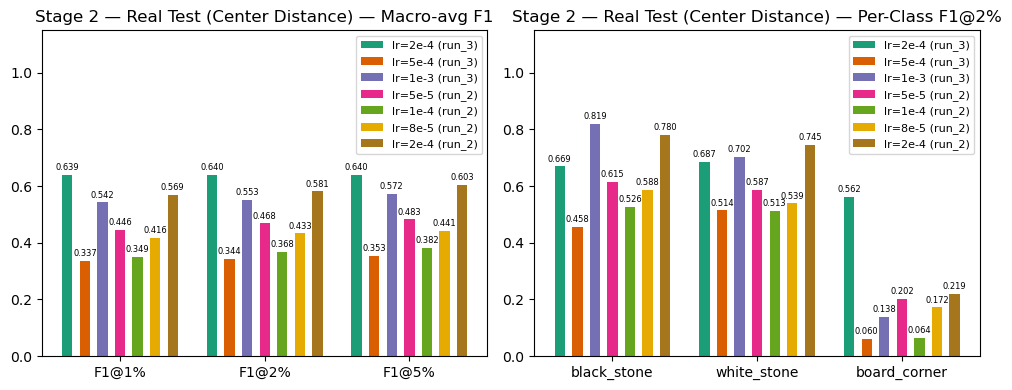

In [27]:
THRESHOLD = 0.03

# Stage 1 (center-distance)
ds_synthetic.set_transform(make_eval_transform(ip_stage1))
cd_s1_synth = evaluate_center_distance(
    model=model_stage1,
    dataset=ds_synthetic["validation"],
    image_processor=ip_stage1,
    batch_size=8,
    threshold=THRESHOLD,
)
ds_real.set_transform(make_eval_transform(ip_stage1))
cd_s1_real = evaluate_center_distance(
    model=model_stage1,
    dataset=ds_real["test"],
    image_processor=ip_stage1,
    batch_size=8,
    threshold=THRESHOLD,
)

# Stage 2 runs (center-distance)
cd_s2 = {}
for label, entry in stage2_models.items():
    ds_real.set_transform(make_eval_transform(entry["ip"]))
    cd_s2[label] = evaluate_center_distance(
        model=entry["model"],
        dataset=ds_real["test"],
        image_processor=entry["ip"],
        batch_size=8,
        threshold=THRESHOLD,
    )

# Plots
if cd_s2:
    plot_center_distance_comparison(cd_s2, title="Stage 2 — Real Test (Center Distance)")

## Browse Predictions

Interactive widget to browse model predictions on dataset samples.


In [28]:
from moku.viz import browse_predictions

# Build model registry
all_models = {"Stage 1 (synthetic)": {"model": model_stage1.to(device), "image_processor": ip_stage1}}
for label, entry in stage2_models.items():
    all_models[f"Stage 2 ({label})"] = {"model": entry["model"].to(device), "image_processor": entry["ip"]}

# Build dataset registry
all_datasets = {"Real": ds_real, "Synthetic": ds_synthetic}

browse_predictions(all_models, all_datasets, threshold=THRESHOLD)